# ResNet-50 From Scratch

This notebook establishes the first model baseline for the Oxford-IIIT Pet classification task.

The main question is:

> **How well can ResNet-50 learn the 37-class pet-breed classification task when all model parameters are initialized randomly?**

The experiment establishes:

$$
\boxed{\text{E0 — ResNet-50 From Scratch}}
$$

The experiment will later be compared with an ImageNet-pretrained ResNet-50.

The overall experimental progression is:

```mermaid
flowchart LR
    A["Oxford-IIIT Pet"] --> B["ResNet-50"]
    B --> C["Random Initialization"]
    C --> D["Train All Parameters"]
    D --> E["Validation"]
    E --> F["E0 Baseline"]
```

The key distinction is:

> **From scratch refers to parameter initialization, not manual implementation of the ResNet-50 architecture.**

## Reproducibility and Configuration

The purpose of E0 is to establish a stable and reproducible baseline.

The following factors should remain controlled:

- dataset split
- input resolution
- preprocessing
- batch size
- optimizer
- learning rate
- weight decay
- scheduler
- number of epochs
- model architecture
- random seed

The main experimental variable is the initialization strategy.

For E0:

$$
\theta_0 \sim \text{Random Initialization}
$$

Later, E1 will use:

$$
\theta_0 = \theta_{\text{ImageNet}}
$$

Using the same training protocol for E0 and E1 makes the effect of pretraining easier to interpret.

In [1]:
import copy
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn

from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from torchvision.datasets import OxfordIIITPet
from torchvision.models import resnet50
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Seed:", SEED)
print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Seed: 42
Device: cuda
GPU: NVIDIA GeForce GTX 1650


## Dataset and Experiment Configuration

The experiment uses the Oxford-IIIT Pet dataset for a 37-class breed classification task.

The dataset protocol is:

- Oxford-IIIT Pet
- 37 breed categories
- Official `trainval` / `test` split
- Stratified 80/20 split of the official `trainval` partition
- Fixed random seed of 42
- Input resolution of $224\times224$
- ImageNet normalization
- Consistent training and evaluation transforms

The experiment follows:

```mermaid
flowchart LR
    A["Oxford-IIIT Pet"] --> B["TrainVal"]
    A --> C["Test"]

    B --> D["Train"]
    B --> E["Validation"]

    D --> F["Model Optimization"]
    E --> G["Model Selection"]
    C --> H["Final Evaluation"]
```

The official test set is reserved for final evaluation.

In [2]:
DATA_ROOT = Path("../data/raw")

IMAGE_SIZE = 224

IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)

dataset_trainval = OxfordIIITPet(
    root=DATA_ROOT,
    split="trainval",
    target_types="category",
    download=False,
)

dataset_test = OxfordIIITPet(
    root=DATA_ROOT,
    split="test",
    target_types="category",
    download=False,
)

print("Official trainval:", len(dataset_trainval))
print("Official test:", len(dataset_test))
print("Number of classes:", len(dataset_trainval.classes))

Official trainval: 3680
Official test: 3669
Number of classes: 37


### Train / Validation Split

The official `trainval` partition is divided into training and validation subsets using a stratified 80/20 split.

$$
\text{Official TrainVal}
\rightarrow
\text{80\% Train}
+
\text{20\% Validation}
$$

The split uses:

$$
\text{random\_state}=42
$$

Stratification preserves approximately the same class proportions between the training and validation subsets.

The same split will be used throughout the subsequent experiments.

In [3]:
indices = np.arange(len(dataset_trainval))
labels = np.array(dataset_trainval._labels)

train_indices, val_indices = train_test_split(
    indices,
    test_size=0.2,
    random_state=SEED,
    stratify=labels,
)

print("Train samples:", len(train_indices))
print("Validation samples:", len(val_indices))
print("Test samples:", len(dataset_test))

Train samples: 2944
Validation samples: 736
Test samples: 3669


### Image Preprocessing

The baseline preprocessing pipeline differs between training and evaluation.

For training:

```mermaid
flowchart LR
    A["Original Image"] --> B["RandomResizedCrop"]
    B --> C["RandomHorizontalFlip"]
    C --> D["ToTensor"]
    D --> E["ImageNet Normalization"]
    E --> F["224 × 224 Tensor"]
```

For validation and test:

```text
Resize → CenterCrop → ToTensor → Normalize
```

The baseline intentionally uses simple augmentation.

More aggressive augmentation will be introduced later as a separate experiment.

In [4]:
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(IMAGE_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=IMAGENET_MEAN,
        std=IMAGENET_STD,
    ),
])

eval_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=IMAGENET_MEAN,
        std=IMAGENET_STD,
    ),
])

In [5]:
class OxfordPetSubset(Dataset):
    def __init__(
        self,
        base_dataset,
        indices,
        transform=None,
    ):
        self.base_dataset = base_dataset
        self.indices = np.asarray(indices)
        self.transform = transform

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, index):
        real_index = self.indices[index]

        image, label = self.base_dataset[real_index]

        if self.transform is not None:
            image = self.transform(image)

        return image, label

In [6]:
train_dataset = OxfordPetSubset(
    base_dataset=dataset_trainval,
    indices=train_indices,
    transform=train_transform,
)

val_dataset = OxfordPetSubset(
    base_dataset=dataset_trainval,
    indices=val_indices,
    transform=eval_transform,
)

test_dataset = OxfordPetSubset(
    base_dataset=dataset_test,
    indices=np.arange(len(dataset_test)),
    transform=eval_transform,
)

print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Test:", len(test_dataset))

Train: 2944
Validation: 736
Test: 3669


### DataLoader Configuration

The datasets are converted into mini-batches before being passed to ResNet-50.

The training loader shuffles the training data, while the validation and test loaders preserve a deterministic order.

The initial batch size is:

$$
\text{Batch Size}=16
$$

The remaining DataLoader settings are kept fixed throughout the baseline experiments unless there is a specific reason to change them.

In [7]:
BATCH_SIZE = 16
NUM_WORKERS = 2
PIN_MEMORY = torch.cuda.is_available()

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
)

print("Batch size:", BATCH_SIZE)
print("Number of workers:", NUM_WORKERS)
print("Pin memory:", PIN_MEMORY)

Batch size: 16
Number of workers: 2
Pin memory: True


In [8]:
images, labels = next(iter(train_loader))

print("Images shape:", images.shape)
print("Labels shape:", labels.shape)
print("Label min:", labels.min().item())
print("Label max:", labels.max().item())

Images shape: torch.Size([16, 3, 224, 224])
Labels shape: torch.Size([16])
Label min: 1
Label max: 35


## Build ResNet-50

We use the ResNet-50 implementation provided by Torchvision.

We are **not** manually implementing:

- Bottleneck blocks
- residual connections
- convolutional stages
- downsampling logic

because the purpose of this experiment is to study **training from scratch**, not architecture implementation.

The critical configuration is:

```python
resnet50(weights=None)
```

which means:

$$
\boxed{
\theta_0=\text{Random Initialization}
}
$$

Therefore:

```mermaid
flowchart LR
    A["Torchvision ResNet-50"] --> B["weights=None"]
    B --> C["Randomly Initialized Parameters"]
    C --> D["Train on Oxford-IIIT Pet"]
```

In [9]:
model = resnet50(weights=None)

print(type(model))

<class 'torchvision.models.resnet.ResNet'>


## Verify Model Architecture

The main structure of ResNet-50 is:

```mermaid
flowchart LR
    A["Input"] --> B["Stem"]
    B --> C["Layer 1"]
    C --> D["Layer 2"]
    D --> E["Layer 3"]
    E --> F["Layer 4"]
    F --> G["Global Average Pooling"]
    G --> H["Classifier"]
```

For E0, all of these trainable components are learned from the target dataset.

The important point is not the exact parameter count here, but that the complete representation is learned without pretrained weights.

In [10]:
print("Stem:")
print(model.conv1)

print("\nLayer1:")
print(model.layer1)

print("\nLayer2:")
print(model.layer2)

print("\nLayer3:")
print(model.layer3)

print("\nLayer4:")
print(model.layer4)

print("\nClassifier:")
print(model.fc)

Stem:
Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)

Layer1:
Sequential(
  (0): Bottleneck(
    (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (downsample): Sequential(
      (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
  )
  (1): Bottleneck(
    (conv1): Conv2d(256, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn1): BatchNorm2d(64, ep

## Replace the Classification Head

The original ResNet-50 classifier is designed for ImageNet-1K:

$$
\hat{y}\in\mathbb{R}^{1000}
$$

Our target task contains 37 breeds:

$$
\hat{y}\in\mathbb{R}^{37}
$$

Therefore, we replace only the final fully connected layer.

The backbone architecture remains unchanged.

In [11]:
num_classes = 37

in_features = model.fc.in_features

model.fc = nn.Linear(in_features, num_classes)

print(model.fc)

Linear(in_features=2048, out_features=37, bias=True)


In [12]:
model = model.to(device)

print(
    "Model device:",
    next(model.parameters()).device,
)

Model device: cuda:0


## Verify Trainable Parameters

In the from-scratch experiment, no parameters are frozen.

Therefore:

$$
\text{Trainable Parameters}
=
\text{Total Parameters}
$$

and:

$$
\frac{
\text{Trainable Parameters}
}{
\text{Total Parameters}
}
=1
$$

This will become especially important when we reach Feature Extraction, where the number of trainable parameters will drop substantially.

In [13]:
total_params = sum(
    parameter.numel()
    for parameter in model.parameters()
)

trainable_params = sum(
    parameter.numel()
    for parameter in model.parameters()
    if parameter.requires_grad
)

print(f"Total parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(
    f"Trainable ratio:      "
    f"{trainable_params / total_params:.2%}"
)

Total parameters:     23,583,845
Trainable parameters: 23,583,845
Trainable ratio:      100.00%


## Training Objective

For an input image $x$, ResNet-50 produces a vector of 37 logits:

$$
z=f_\theta(x)
$$

where:

$$
z\in\mathbb{R}^{37}
$$

The class probabilities are:

$$
p_k=
\frac{e^{z_k}}
{\sum_{j=1}^{37}e^{z_j}}
$$

For a target class $y$, the Cross-Entropy loss is:

$$
\mathcal{L}
=
-\log p_y
$$

For the complete training set, the optimization objective is:

$$
\theta^*
=
\arg\min_\theta
\frac{1}{N}
\sum_{i=1}^{N}
\mathcal{L}
\left(
f_\theta(x_i),y_i
\right)
$$

Because this is the scratch baseline:

$$
\theta_0
\sim
\text{Random Initialization}
$$

## Why Training From Scratch Is Challenging

In E0, the model has no previously learned visual representation.

It must learn the hierarchy:

```mermaid
flowchart LR
    A["Random Weights"] --> B["Low-Level Features"]
    B --> C["Mid-Level Features"]
    C --> D["High-Level Features"]
    D --> E["Breed-Specific Representation"]
```

using only the Oxford-IIIT Pet training data.

This is a much harder starting point than an ImageNet-pretrained model.

Therefore, E0 is not intended to be the strongest model.

Its role is to answer:

> **How difficult is the target task when the model starts with no pretrained visual knowledge?**

## Loss Function

Oxford-IIIT Pet is a single-label multi-class classification problem.

Therefore, we use Cross-Entropy Loss.

In [14]:
criterion = nn.CrossEntropyLoss()

## Optimizer

For the initial baseline, we use AdamW.

The main purpose of E0 is not hyperparameter optimization.

Instead, we want a stable training configuration that can later be reused for the pretrained baseline.

Initial configuration:

$$
\eta = 10^{-3}
$$

and:

$$
\lambda = 10^{-4}
$$

where $\eta$ is the learning rate and $\lambda$ is the weight decay.

In [15]:
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4

optimizer = AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)

print("Learning rate:", LEARNING_RATE)
print("Weight decay:", WEIGHT_DECAY)

Learning rate: 0.001
Weight decay: 0.0001


## Learning Rate Scheduler

We use Cosine Annealing for the baseline training run.

The learning rate follows:

$$
\eta_t
=
\eta_{\min}
+
\frac{1}{2}
(\eta_{\max}-\eta_{\min})
\left(
1+\cos\frac{\pi t}{T}
\right)
$$

The scheduler gradually reduces the step size over training.

This is part of the baseline recipe, not yet a hyperparameter study.

The same baseline recipe should later be used for E1 so that the E0 vs E1 comparison remains controlled.

In [16]:
NUM_EPOCHS = 30

scheduler = CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

## Training Loop

Each training step follows the standard optimization process:

```mermaid
flowchart LR
    A["Mini-Batch"] --> B["Forward"]
    B --> C["Logits"]
    C --> D["Loss"]
    D --> E["Backward"]
    E --> F["Gradients"]
    F --> G["Optimizer Step"]
    G --> H["Next Batch"]
```

For one training batch:

$$
x
\rightarrow
f_\theta(x)
\rightarrow
\mathcal{L}
\rightarrow
\nabla_\theta\mathcal{L}
\rightarrow
\theta_{\text{new}}
$$

After all training batches in an epoch, we evaluate the current model on the validation set.

No gradient update is performed during validation.

In [17]:
def train_one_epoch(
    model,
    dataloader,
    criterion,
    optimizer,
    device
): 
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in dataloader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()

        logits = model(images)

        loss = criterion(logits, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item() * images.size(0)

        predictions = torch.argmax(logits, dim=1)

        correct += (predictions == labels).sum().item()

        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_accuracy = correct / total

    return epoch_loss, epoch_accuracy
    

## Validation

Validation is used for model selection.

During validation:

- the model is switched to evaluation mode
- gradients are disabled
- parameters are not updated

The flow is:

```text
Validation Batch → Forward → Loss / Prediction → Metrics
```

The validation result helps us decide which checkpoint is the best E0 model.

In [18]:
def evaluate(
    model,
    dataloader,
    criterion,
    device
):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            logits = model(images)

            loss = criterion(logits, labels)

            running_loss += loss.item() * images.size(0)

            predictions = torch.argmax(logits, dim=1)

            correct += (predictions == labels).sum().item()

            total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_accuracy = correct / total

    return epoch_loss, epoch_accuracy

In [19]:
history = {
    "train_loss": [],
    "train_accuracy": [],
    "val_loss": [],
    "val_accuracy": [],
    "learning_rate": [],
}

## Best Checkpoint

The final epoch is not necessarily the best model.

Therefore, we select the checkpoint with the highest validation accuracy.

The selection process is:

```mermaid
flowchart LR
    A["Epoch"] --> B["Validation Accuracy"]
    B --> C{"Better Than Best?"}
    C -->|Yes| D["Save Checkpoint"]
    C -->|No| E["Keep Previous Best"]
```

The official test set is not involved in this selection.

In [20]:
checkpoint_dir = Path("../experiments/checkpoints")

checkpoint_dir.mkdir(parents=True, exist_ok=True)

best_val_accuracy = 0.0

for epoch in range(NUM_EPOCHS):
    train_loss, train_accuracy = train_one_epoch(
        model=model,
        dataloader=train_loader,
        criterion=criterion,
        optimizer=optimizer,
        device=device
    )

    val_loss, val_accuracy = evaluate(
        model=model,
        dataloader=val_loader,
        criterion=criterion,
        device=device
    )

    current_lr = optimizer.param_groups[0]["lr"]

    history["train_loss"].append(train_loss)
    history["train_accuracy"].append(train_accuracy)
    history["val_loss"].append(val_loss)
    history["val_accuracy"].append(val_accuracy)
    history["learning_rate"].append(current_lr)

    if val_accuracy > best_val_accuracy:
        best_val_accuracy = val_accuracy

        torch.save(
            {
                "epoch": epoch + 1,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "val_accuracy": val_accuracy
            },
            checkpoint_dir / "resnet50_scratch_best.pt"
        )

    scheduler.step()

    print(
        f"Epoch [{epoch + 1:02d}/{NUM_EPOCHS}] | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_accuracy:.2%} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_accuracy:.2%} | "
        f"LR: {current_lr:.2e}"
    )


Epoch [01/30] | Train Loss: 3.8815 | Train Acc: 3.63% | Val Loss: 3.9300 | Val Acc: 4.62% | LR: 1.00e-03
Epoch [02/30] | Train Loss: 3.5965 | Train Acc: 5.06% | Val Loss: 3.5480 | Val Acc: 7.34% | LR: 9.97e-04
Epoch [03/30] | Train Loss: 3.5619 | Train Acc: 5.57% | Val Loss: 3.5758 | Val Acc: 6.79% | LR: 9.89e-04
Epoch [04/30] | Train Loss: 3.5251 | Train Acc: 6.66% | Val Loss: 3.4585 | Val Acc: 6.52% | LR: 9.76e-04
Epoch [05/30] | Train Loss: 3.5365 | Train Acc: 5.60% | Val Loss: 4.3189 | Val Acc: 5.30% | LR: 9.57e-04
Epoch [06/30] | Train Loss: 3.5283 | Train Acc: 6.35% | Val Loss: 3.4758 | Val Acc: 6.52% | LR: 9.33e-04
Epoch [07/30] | Train Loss: 3.4716 | Train Acc: 6.79% | Val Loss: 3.4300 | Val Acc: 8.56% | LR: 9.05e-04
Epoch [08/30] | Train Loss: 3.4907 | Train Acc: 6.18% | Val Loss: 3.5174 | Val Acc: 6.79% | LR: 8.72e-04
Epoch [09/30] | Train Loss: 3.4578 | Train Acc: 6.96% | Val Loss: 3.3801 | Val Acc: 8.29% | LR: 8.35e-04
Epoch [10/30] | Train Loss: 3.4138 | Train Acc: 7.78% |

## Load the Best Validation Checkpoint

After training, we restore the checkpoint with the best validation accuracy.

This ensures that the E0 result does not depend on the final epoch if validation performance has already started to degrade.

In [21]:
checkpoint = torch.load(
    checkpoint_dir / "resnet50_scratch_best.pt",
    map_location=device
)

model.load_state_dict(checkpoint["model_state_dict"])

best_epoch = checkpoint["epoch"]

print("Best epoch:", best_epoch)
print(
    "Best validation accuracy:",
    f"{checkpoint['val_accuracy']:.2%}",
)

Best epoch: 29
Best validation accuracy: 27.72%


## Learning Curves

Training and validation curves allow us to inspect the optimization dynamics.

We are interested in:

- whether training loss decreases
- whether validation loss decreases
- whether training and validation accuracy diverge
- whether the model begins to overfit

The curve must be interpreted from the actual experiment rather than assuming a particular outcome.

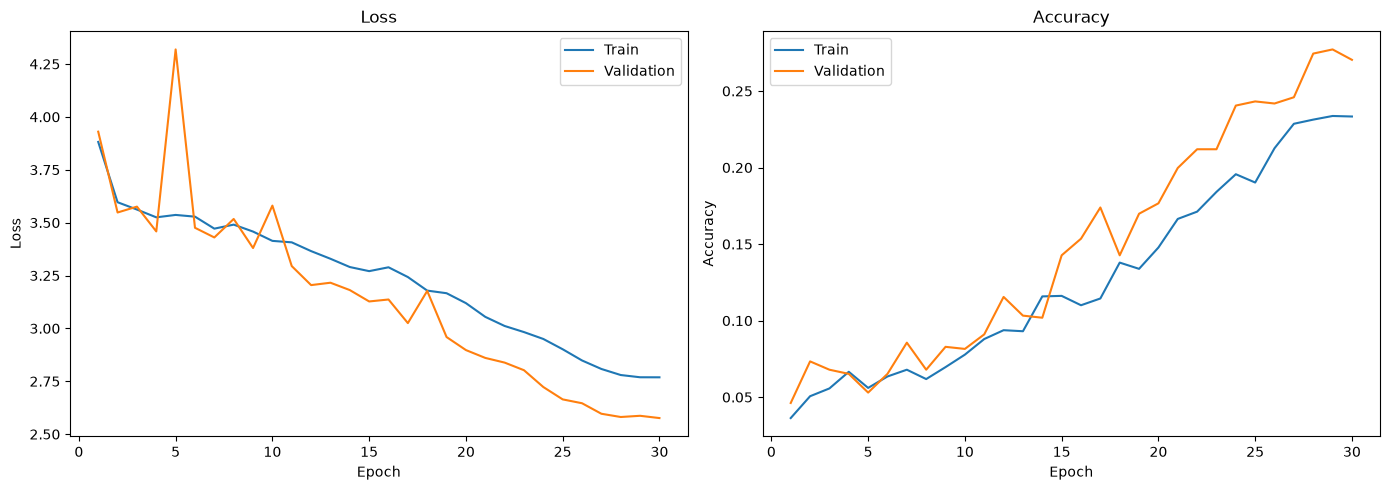

In [22]:
epochs = range(
    1,
    NUM_EPOCHS + 1,
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5),
)

axes[0].plot(
    epochs,
    history["train_loss"],
    label="Train",
)

axes[0].plot(
    epochs,
    history["val_loss"],
    label="Validation",
)

axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

axes[1].plot(
    epochs,
    history["train_accuracy"],
    label="Train",
)

axes[1].plot(
    epochs,
    history["val_accuracy"],
    label="Validation",
)

axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()

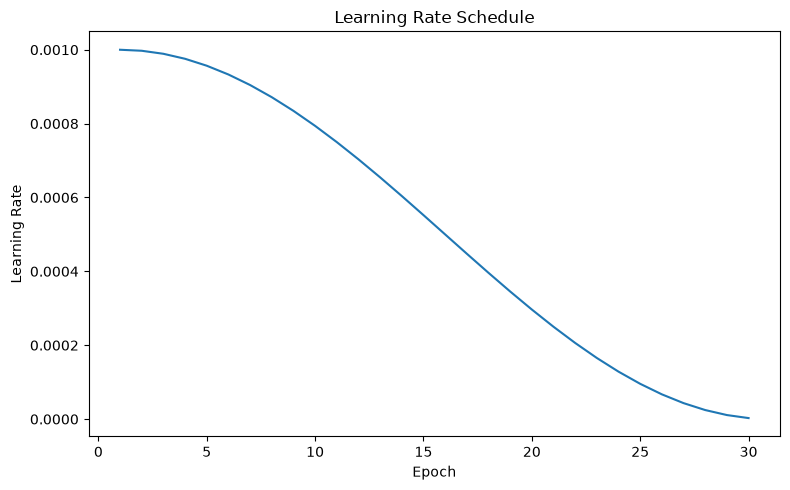

In [23]:
plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    history["learning_rate"],
)

plt.xlabel("Epoch")
plt.ylabel("Learning Rate")
plt.title("Learning Rate Schedule")

plt.tight_layout()
plt.show()

## Validation Evaluation

The E0 model is selected using validation performance.

At this stage, we report:

- validation loss
- validation accuracy

More detailed metrics such as Macro-F1, confusion matrix, and per-class performance will be handled in the dedicated evaluation phase.

In [25]:
best_val_loss, best_val_accuracy = evaluate(
    model=model,
    dataloader=val_loader,
    criterion=criterion,
    device=device,
)

print(
    f"Best Validation Loss: "
    f"{best_val_loss:.4f}"
)

print(
    f"Best Validation Accuracy: "
    f"{best_val_accuracy:.2%}"
)

Best Validation Loss: 2.5869
Best Validation Accuracy: 27.72%


## Final Evaluation on the Test Set

After selecting the best E0 checkpoint using the validation set, we evaluate the model once on the official test set.

The evaluation protocol is:

```mermaid
flowchart LR
    A["Train"] --> B["Optimize Parameters"]
    B --> C["Validation"]
    C --> D["Select Best Checkpoint"]
    D --> E["Official Test Set"]
    E --> F["Final E0 Test Result"]
```

The test set is not used to tune the model or select hyperparameters.

Therefore, the test result provides the final evaluation of the selected E0 configuration on unseen data.

In [26]:
test_loss, test_accuracy = evaluate(
    model=model,
    dataloader=test_loader,
    criterion=criterion,
    device=device,
)

print(f"E0 Test Loss: {test_loss:.4f}")
print(f"E0 Test Accuracy: {test_accuracy:.2%}")

E0 Test Loss: 2.6688
E0 Test Accuracy: 24.99%


## E0 Baseline Result

We now summarize the complete E0 experiment.

The result records:

- model architecture
- initialization strategy
- number of trainable parameters
- training configuration
- best validation performance
- final test performance

The validation metrics are used for model selection, while the test metrics are used only for final evaluation.

In [27]:
baseline_result = pd.DataFrame([{
    "experiment": "E0",
    "model": "ResNet-50",
    "initialization": "Random",
    "trainable_params": trainable_params,
    "epochs": NUM_EPOCHS,
    "batch_size": BATCH_SIZE,
    "learning_rate": LEARNING_RATE,
    "weight_decay": WEIGHT_DECAY,
    "best_epoch": best_epoch,
    "best_val_accuracy": best_val_accuracy,
    "best_val_loss": best_val_loss,
    "test_accuracy": test_accuracy,
    "test_loss": test_loss,
}])

baseline_result

,experiment,model,initialization,trainable_params,epochs,batch_size,learning_rate,weight_decay,best_epoch,best_val_accuracy,best_val_loss,test_accuracy,test_loss
0,E0,ResNet-50,Random,23583845,30,16,0.001,0.0001,29,0.277174,2.586909,0.249932,2.66883


## E0 Result Interpretation

The E0 result provides two complementary measurements:

### Validation Performance

Validation performance was used to select the best checkpoint.

### Test Performance

Test performance measures how the selected checkpoint generalizes to the unseen official test set.

The important distinction is:

$$
\text{Validation}
\rightarrow
\text{Model Selection}
$$

while:

$$
\text{Test}
\rightarrow
\text{Final Evaluation}
$$

Therefore, the test result is recorded only after the E0 configuration has been selected using validation performance.